## import libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from imblearn.over_sampling import SMOTE
from ctgan import CTGAN
import os
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import RepeatedStratifiedKFold
import keras_tuner as kt
from scipy.stats import wilcoxon

## LOAD FINAL DATASET

In [57]:
os.environ["LOKY_MAX_CPU_COUNT"] = "16"

def ensure_minimum_class_samples(X, y, min_samples=2):
    """
    Ensure each class in y has at least min_samples.
    Duplicate rows for classes with too few samples.
    """
    unique_classes, counts = np.unique(y, return_counts=True)
    for cls, count in zip(unique_classes, counts):
        if count < min_samples:
            idx = np.where(y == cls)[0]
            repeat_factor = min_samples - count
            X = np.concatenate([X, X[idx][:repeat_factor]], axis=0)
            y = np.concatenate([y, y[idx][:repeat_factor]], axis=0)
            print(f"Class {cls} had {count} sample(s); duplicated to reach {min_samples}.")
    return X, y

def augment_with_ctgan_smote(df, target_samples=1000):
    """Augment a small dataset using CTGAN followed by SMOTE to reach target_samples with binary classes 0 and 1."""
    # Identify the target column (last column)
    target_col = df.columns[-1]
    
    # Separate features and labels
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]
    
    print(f"Original samples: {len(df)}")
    print("Original class distribution:", y.value_counts().to_dict())
    
    # --- Step 1: CTGAN augmentation ---
    # If the dataset is smaller than target, generate synthetic samples.
    if len(df) < target_samples:
        df_for_ctgan = df.copy()
        # Convert target to string so CTGAN treats it as a categorical variable
        df_for_ctgan[target_col] = df_for_ctgan[target_col].astype(str)
        
        ctgan = CTGAN(
            epochs=500,            # More epochs for improved learning on small datasets
            batch_size=20,         # Smaller batch size for efficiency
            verbose=True,
            cuda=True if os.environ.get("CUDA_VISIBLE_DEVICES") else False
        )
        # Identify categorical features (excluding the target column)
        categorical_features = [col for col in X.columns if X[col].nunique() < 10]
        
        # Train CTGAN on the dataset
        ctgan.fit(df_for_ctgan, categorical_features + [target_col])
        
        # Calculate how many synthetic samples to generate
        samples_to_generate = max(100, target_samples - len(df))
        synthetic_data = ctgan.sample(samples_to_generate)
        
        # Filter synthetic data to keep only valid binary labels ("0" or "1")
        synthetic_data = synthetic_data[synthetic_data[target_col].isin(["0", "1"])]
        # Convert the target column back to integer type
        synthetic_data[target_col] = synthetic_data[target_col].astype(int)
        
        # Combine real and synthetic data
        augmented_df = pd.concat([df, synthetic_data], ignore_index=True)
    else:
        augmented_df = df.copy()
    
    # --- Step 2: SMOTE for balancing ---
    X_aug = augmented_df.iloc[:, :-1].values
    y_aug = augmented_df.iloc[:, -1].values
    
    # Create nearest neighbors estimator for SMOTE
    nn_estimator = NearestNeighbors(n_neighbors=min(5, len(X_aug) - 1))
    
    try:
        smote = SMOTE(
            sampling_strategy='auto',
            random_state=42,
            k_neighbors=nn_estimator
        )
        X_resampled, y_resampled = smote.fit_resample(X_aug, y_aug)
        print(f"\nAfter CTGAN+SMOTE augmentation: {len(X_resampled)} samples")
        unique, counts = np.unique(y_resampled, return_counts=True)
        print("Augmented class distribution:", dict(zip(unique, counts)))
    except ValueError as e:
        print(f"SMOTE failed: {e}")
        print("Using CTGAN augmented data without SMOTE")
        X_resampled, y_resampled = X_aug, y_aug
    
    # Ensure that each class has at least two samples (needed for stratified splitting)
    X_resampled, y_resampled = ensure_minimum_class_samples(X_resampled, y_resampled, min_samples=2)
    
    return X_resampled, y_resampled

def load_and_augment_data():
    """Load, augment, and prepare data for training."""
    df_selected = pd.read_csv('reduced_features_and_labels.csv')  # Keep df_selected available
    # Augment data (targeting 900 samples with binary class labels)
    X_resampled, y_resampled = augment_with_ctgan_smote(df_selected, target_samples=1000)
    
    # Split into training and testing sets with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, 
        y_resampled, 
        test_size=0.2,
        stratify=y_resampled,
        random_state=42
    )
    
    # Apply standard scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Convert labels to one-hot encoding
    y_train_cat = to_categorical(y_train, num_classes=2)
    y_test_cat = to_categorical(y_test, num_classes=2)
    
    print(f"\nFinal dataset shapes:")
    print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"y_train_cat: {y_train_cat.shape}, y_test_cat: {y_test_cat.shape}")
    
    return df_selected, X_train, X_test, y_train_cat, y_test_cat, scaler

# Execute the optimized augmentation pipeline
df_selected, X_train, X_test, y_train_cat, y_test_cat, scaler = load_and_augment_data()

Original samples: 47
Original class distribution: {1: 32, 0: 15}


Gen. (-2.04) | Discrim. (-0.26): 100%|███████████████████████████████████████████████| 500/500 [02:03<00:00,  4.06it/s]



After CTGAN+SMOTE augmentation: 1382 samples
Augmented class distribution: {0: 691, 1: 691}

Final dataset shapes:
X_train: (1105, 86), X_test: (277, 86)
y_train_cat: (1105, 2), y_test_cat: (277, 2)


## Multilayer Perceptron NEURAL NETWORK

In [75]:
# Function to build the model
def build_model(hp):
    model = models.Sequential()
    model.add(layers.Dense(hp.Int('units1', min_value=256, max_value=1024, step=128), 
                           activation='relu', input_shape=(X_train.shape[1],)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(hp.Float('dropout1', min_value=0.1, max_value=0.4, step=0.1)))

    model.add(layers.Dense(hp.Int('units2', min_value=128, max_value=512, step=128), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(hp.Float('dropout2', min_value=0.1, max_value=0.4, step=0.1)))

    model.add(layers.Dense(hp.Int('units3', min_value=64, max_value=256, step=64), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(hp.Float('dropout3', min_value=0.1, max_value=0.4, step=0.1)))

    model.add(layers.Dense(2, activation='softmax'))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=hp.Choice('learning_rate', [0.01, 0.001, 0.0001])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Set up the tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=50,
    factor=3,
    directory='hyperparameter_tuning',
    project_name='irpso_nn'
)

# Callbacks for training
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-6)
]

# Tune the hyperparameters using only the training data
tuner.search(X_train, y_train_cat, epochs=50, validation_data=(X_test, y_test_cat), callbacks=callbacks_list)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Run the model multiple times for stability
num_runs = 5
metrics_results = { 'accuracy': [], 'sensitivity': [], 'specificity': [], 'precision': [], 
                    'f1': [], 'auc_roc': [], 'pr_auc': [], 'mcc': [] }

for i in range(num_runs):
    print(f"\n Training Model - Run {i+1}/{num_runs}")

    # Build a new model instance
    model = tuner.hypermodel.build(best_hps)
    
    # Train model
    history = model.fit(X_train, y_train_cat, 
              epochs=200, batch_size=32, 
              validation_data=(X_test, y_test_cat),
              callbacks=callbacks_list,
              verbose=0)
    
    # Predictions
    y_test_pred_prob = model.predict(X_test)
    y_test_pred = np.argmax(y_test_pred_prob, axis=1)
    y_test_true = np.argmax(y_test_cat, axis=1)
    
    # Evaluate
    test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
    sensitivity = recall_score(y_test_true, y_test_pred)
    precision = precision_score(y_test_true, y_test_pred)
    f1 = f1_score(y_test_true, y_test_pred)
    mcc = matthews_corrcoef(y_test_true, y_test_pred)
    auc_roc = roc_auc_score(y_test_true, y_test_pred_prob[:, 1])
    pr_auc = average_precision_score(y_test_true, y_test_pred_prob[:, 1])
    
    # Specificity
    tn, fp, fn, tp = confusion_matrix(y_test_true, y_test_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0.0

    # Store results
    metrics_results['accuracy'].append(test_acc)
    metrics_results['sensitivity'].append(sensitivity)
    metrics_results['specificity'].append(specificity)
    metrics_results['precision'].append(precision)
    metrics_results['f1'].append(f1)
    metrics_results['auc_roc'].append(auc_roc)
    metrics_results['pr_auc'].append(pr_auc)
    metrics_results['mcc'].append(mcc)
    
    print(f"Run {i+1} metrics:")
    print(f" - Accuracy: {test_acc:.4f}")
    print(f" - Sensitivity (Recall): {sensitivity:.4f}")
    print(f" - Specificity: {specificity:.4f}")
    print(f" - Precision: {precision:.4f}")
    print(f" - F1 Score: {f1:.4f}")
    print(f" - AUC-ROC: {auc_roc:.4f}")
    print(f" - PR-AUC: {pr_auc:.4f}")
    print(f" - MCC: {mcc:.4f}")

# Report Mean & Standard Deviation
print("\nFinal Performance Metrics (Mean ± Std across 5 runs):")
for metric_name, values in metrics_results.items():
    mean_score = np.mean(values)
    std_score = np.std(values)
    print(f"{metric_name.capitalize()}: {mean_score:.4f} ± {std_score:.4f}")


Reloading Tuner from hyperparameter_tuning\irpso_nn\tuner0.json

 Training Model - Run 1/5
9/9 [==============================] - 0s 2ms/step
Run 1 metrics:
 - Accuracy: 0.9025
 - Sensitivity (Recall): 0.8841
 - Specificity: 0.9209
 - Precision: 0.9173
 - F1 Score: 0.9004
 - AUC-ROC: 0.9665
 - PR-AUC: 0.9660
 - MCC: 0.8056

 Training Model - Run 2/5
9/9 [==============================] - 0s 1ms/step
Run 2 metrics:
 - Accuracy: 0.8628
 - Sensitivity (Recall): 0.7681
 - Specificity: 0.9568
 - Precision: 0.9464
 - F1 Score: 0.8480
 - AUC-ROC: 0.9492
 - PR-AUC: 0.9504
 - MCC: 0.7386

 Training Model - Run 3/5
9/9 [==============================] - 0s 1ms/step
Run 3 metrics:
 - Accuracy: 0.8845
 - Sensitivity (Recall): 0.8623
 - Specificity: 0.9065
 - Precision: 0.9015
 - F1 Score: 0.8815
 - AUC-ROC: 0.9598
 - PR-AUC: 0.9604
 - MCC: 0.7696

 Training Model - Run 4/5
9/9 [==============================] - 0s 2ms/step
Run 4 metrics:
 - Accuracy: 0.8773
 - Sensitivity (Recall): 0.8188
 - Speci

In [76]:
baseline = 0.5

print("\nWilcoxon Signed-Rank Test Results (vs baseline = 0.50):")
print("-" * 60)
for metric_name, values in metrics_results.items():
    try:
        stat, p_value = wilcoxon(values, alternative='greater', zero_method='wilcox')
        mean_val = np.mean(values)
        print(f"{metric_name.capitalize():<12}: stat = {stat:.4f}, p = {p_value:.4f} | mean = {mean_val:.4f}")
        if p_value < 0.05:
            print(f" => Statistically significant: {metric_name} > {baseline}\n")
        else:
            print(f" => Not statistically significant: cannot conclude {metric_name} > {baseline}\n")
    except ValueError as e:
        print(f"{metric_name.capitalize():<12}: Wilcoxon test failed — {str(e)}\n")


Wilcoxon Signed-Rank Test Results (vs baseline = 0.50):
------------------------------------------------------------
Accuracy    : stat = 15.0000, p = 0.0312 | mean = 0.8830
 => Statistically significant: accuracy > 0.5

Sensitivity : stat = 15.0000, p = 0.0312 | mean = 0.8348
 => Statistically significant: sensitivity > 0.5

Specificity : stat = 15.0000, p = 0.0312 | mean = 0.9309
 => Statistically significant: specificity > 0.5

Precision   : stat = 15.0000, p = 0.0312 | mean = 0.9239
 => Statistically significant: precision > 0.5

F1          : stat = 15.0000, p = 0.0312 | mean = 0.8762
 => Statistically significant: f1 > 0.5

Auc_roc     : stat = 15.0000, p = 0.0312 | mean = 0.9584
 => Statistically significant: auc_roc > 0.5

Pr_auc      : stat = 15.0000, p = 0.0312 | mean = 0.9579
 => Statistically significant: pr_auc > 0.5

Mcc         : stat = 15.0000, p = 0.0312 | mean = 0.7706
 => Statistically significant: mcc > 0.5



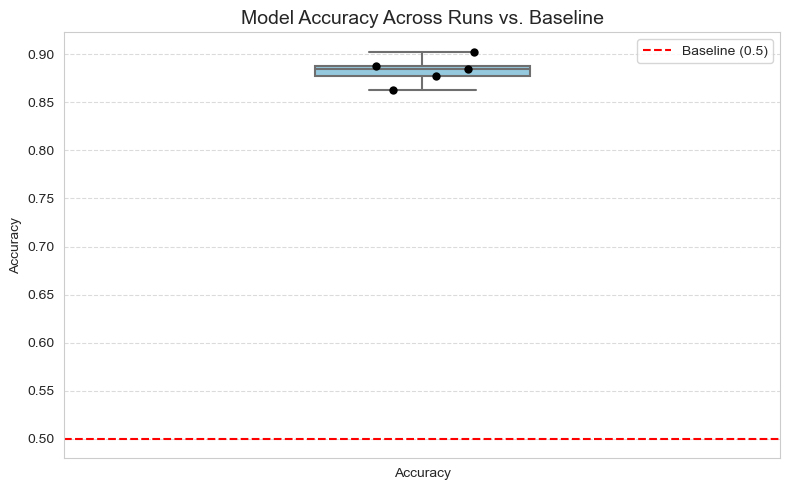

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=metrics_results['accuracy'], color='skyblue', width=0.3)
sns.stripplot(data=metrics_results['accuracy'], color='black', jitter=True, size=6)

plt.axhline(0.5, color='red', linestyle='--', label='Baseline (0.5)')
plt.title('Model Accuracy Across Runs vs. Baseline', fontsize=14)
plt.ylabel('Accuracy')
plt.xticks([0], ['Accuracy'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


=============== MLP Model Summary ================

Architecture:
Input: 86 features
Hidden 1: 1024 units (Dropout: 0.3)
Hidden 2: 512 units (Dropout: 0.3)
Hidden 3: 64 units (Dropout: 0.3)
Output: 2 units (softmax)

Training:
Learning Rate: 1e-03
Epochs Trained: 18


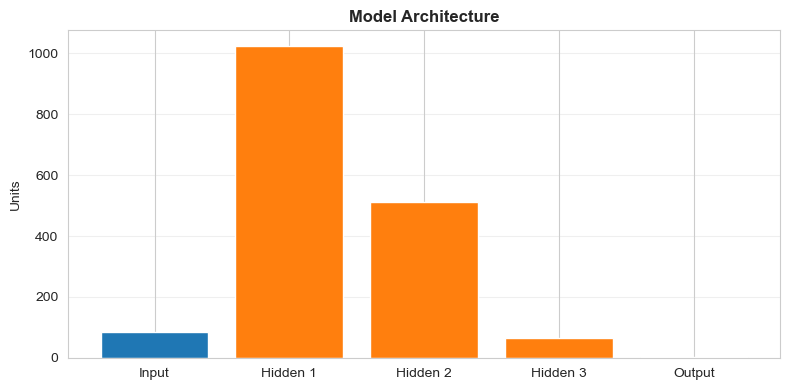

In [78]:
print(f"\n{' MLP Model Summary ':=^50}")
print(f"\nArchitecture:")
print(f"Input: {X_train.shape[1]} features")
print(f"Hidden 1: {best_hps.get('units1')} units (Dropout: {best_hps.get('dropout1'):.1f})")
print(f"Hidden 2: {best_hps.get('units2')} units (Dropout: {best_hps.get('dropout2'):.1f})")
print(f"Hidden 3: {best_hps.get('units3')} units (Dropout: {best_hps.get('dropout3'):.1f})")
print(f"Output: 2 units (softmax)")
print(f"\nTraining:")
print(f"Learning Rate: {best_hps.get('learning_rate'):.0e}")
print(f"Epochs Trained: {len(history.history['val_accuracy'])}")

plt.figure(figsize=(8, 4))
layers_MLP = ['Input'] + [f'Hidden {i+1}' for i in range(3)] + ['Output']
units = [X_train.shape[1]] + [best_hps.get(f'units{i+1}') for i in range(3)] + [2]

plt.bar(layers_MLP, units, color=['#1f77b4', '#ff7f0e', '#ff7f0e', '#ff7f0e', '#2ca02c'])
plt.title('Model Architecture', fontweight='bold')
plt.ylabel('Units')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Set seaborn style

In [79]:
sns.set_style("whitegrid")

## Accuracy & Loss Curves

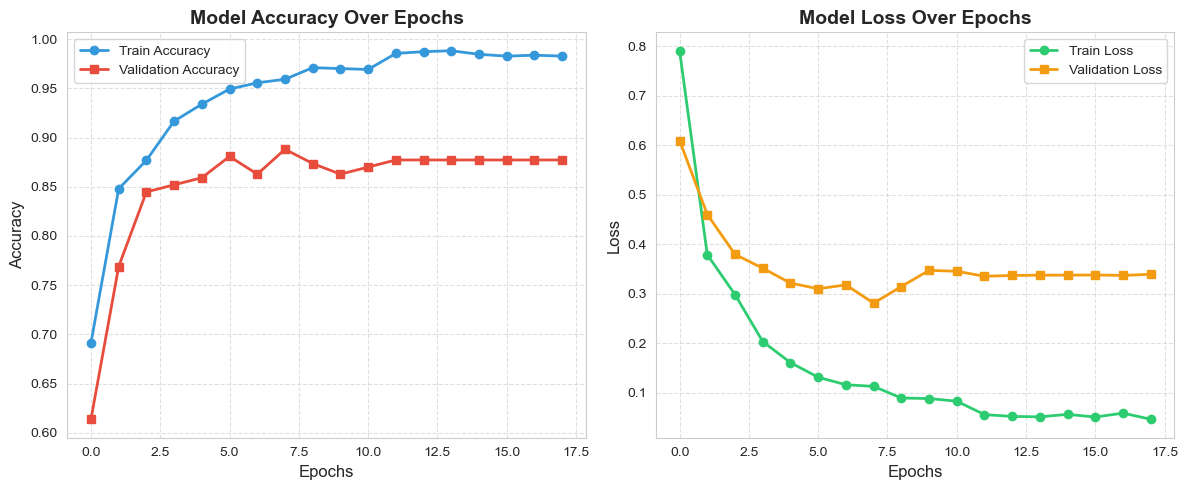

In [80]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color="#3498DB", marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color="#E74C3C", marker='s')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2, color="#2ECC71", marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color="#F39C12", marker='s')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Confusion Matrix Heatmap

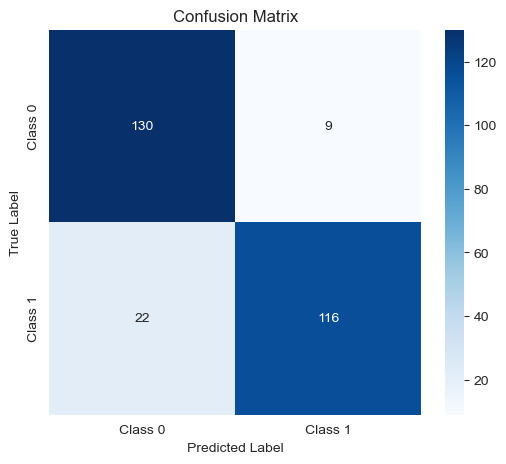

In [81]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## ROC Curve

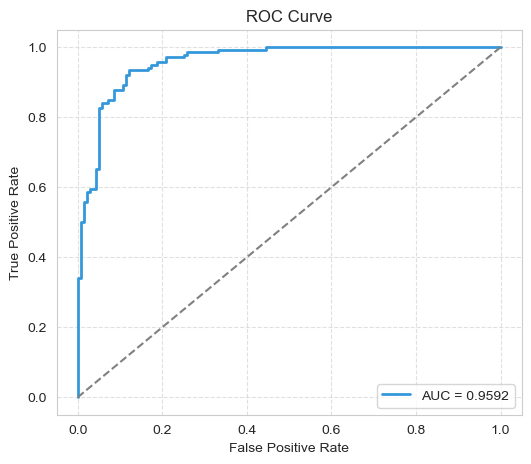

In [82]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test_true, y_test_pred_prob[:, 1])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#3498DB', linewidth=2, label=f'AUC = {auc_roc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Precision-Recall Curve

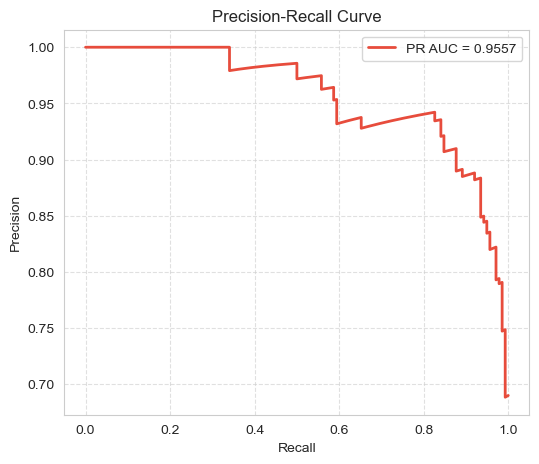

In [83]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(y_test_true, y_test_pred_prob[:, 1])

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, color='#E74C3C', linewidth=2, label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Learning Rate Scheduler

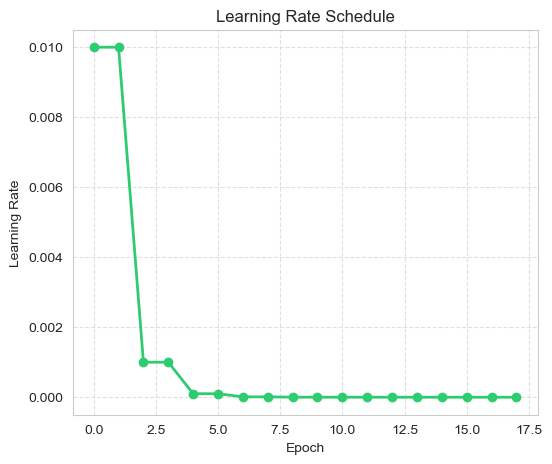

In [84]:
lrs = [0.01 * (0.1 ** (i // 2)) for i in range(len(history.history['loss']))]

plt.figure(figsize=(6, 5))
plt.plot(lrs, color='#2ECC71', linewidth=2, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Feature Correlation Heatmap

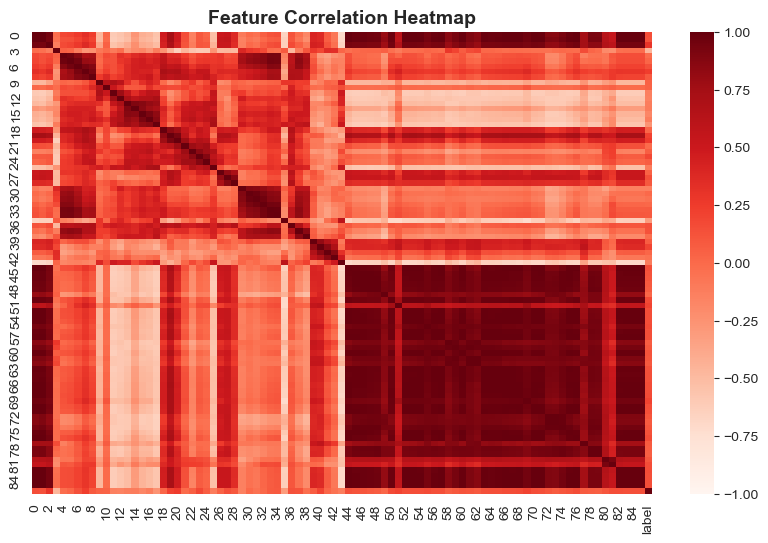

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_selected.corr(), annot=False, cmap="Reds", fmt='.2f', vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()

## SHAP Analysis

In [85]:
explainer = shap.Explainer(model, X_train)  
shap_values = explainer(X_test)

PermutationExplainer explainer: 278it [00:11,  3.51it/s]                                                               


## SHAP Summary Plot

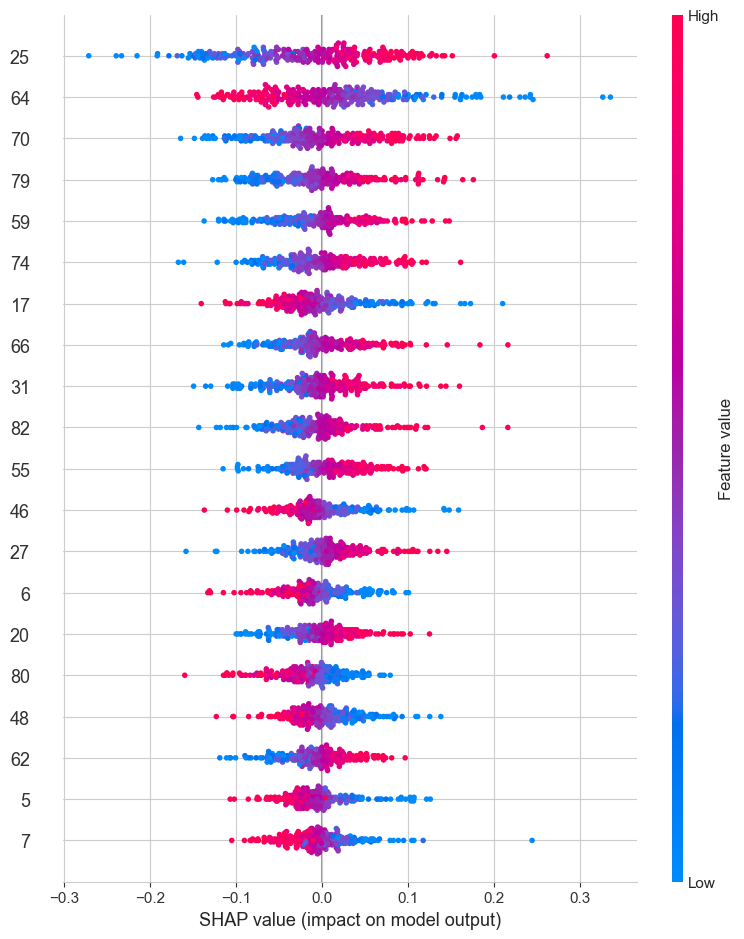

In [86]:
feature_names = df_selected.columns[:X_test.shape[1]]
shap_values_class_1 = shap_values.values[..., 1]  
shap.summary_plot(shap_values_class_1, X_test, feature_names=feature_names)

## Pareto Plot of Feature Importance

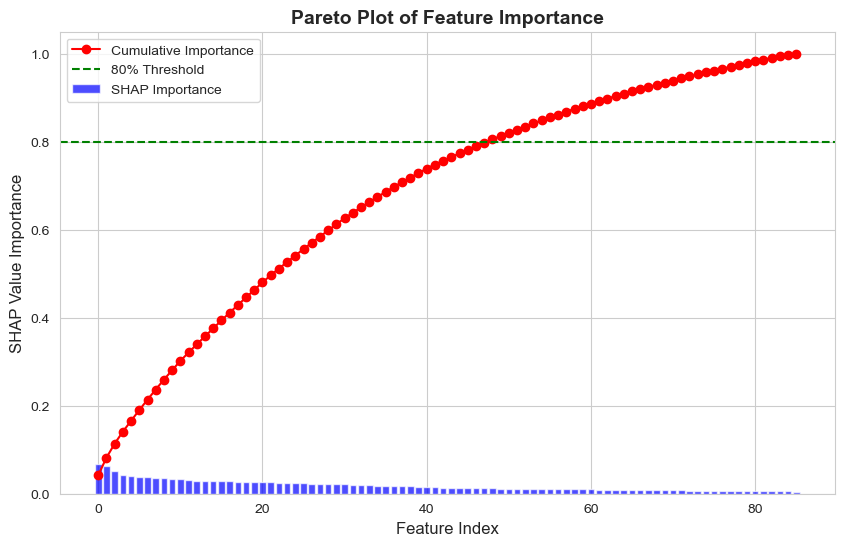

In [87]:
shap_importance = np.abs(shap_values.values).mean(axis=(0, 2))
shap_sorted_idx = np.argsort(shap_importance)[::-1]
shap_cumulative = np.cumsum(shap_importance[shap_sorted_idx]) / np.sum(shap_importance)

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_names)), shap_importance[shap_sorted_idx], color='b', alpha=0.7, label='SHAP Importance')
plt.plot(range(len(feature_names)), shap_cumulative, color='r', marker='o', label='Cumulative Importance')
plt.axhline(0.8, color='g', linestyle='--', label='80% Threshold')
plt.xlabel("Feature Index", fontsize=12)
plt.ylabel("SHAP Value Importance", fontsize=12)
plt.title("Pareto Plot of Feature Importance", fontsize=14, fontweight='bold')
plt.legend()
plt.show()

## Results with traditional algorithms

In [72]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    matthews_corrcoef, roc_auc_score, average_precision_score, confusion_matrix, make_scorer)

# Convert one-hot encoded labels to single-label format for traditional ML models
y_train_ml = np.argmax(y_train_cat, axis=1)
y_test_ml = np.argmax(y_test_cat, axis=1)

# Define classifiers and their hyperparameter grids
param_grids = {
        "RandomForest": (
            RandomForestClassifier(random_state=42, n_jobs=-1),
            {"n_estimators": [200, 300, 500],
             "max_depth": [5, 10, 15, None]}
        ),
        "LogisticRegression": (LogisticRegression(random_state=42, solver='liblinear', max_iter=1000),
            {"C": [0.001, 0.01, 0.1, 1, 10, 100],
             "penalty": ["l1", "l2"]}  
        ),
        "LinearSVC": (
            LinearSVC(penalty='l2', loss='squared_hinge', dual=False,
                      max_iter=10000, random_state=42),
            {"C": [0.001, 0.01, 0.1, 1, 10, 100]}
        ),
        "XGBoost": (
            xgb.XGBClassifier(eval_metric='mlogloss', tree_method='hist',
                              random_state=42, n_jobs=-1),
            {"n_estimators": [200, 300, 500],
             "learning_rate": [0.01, 0.1, 0.3],
             "max_depth": [6, 9, 12]}
        ),
        "AdaBoost": (
            AdaBoostClassifier(random_state=42),
            {"n_estimators": [200, 300, 500],
             "learning_rate": [0.01, 0.1, 0.3]}
        )
    }

# Repeated stratified K-fold configuration
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
mcc_scorer = make_scorer(matthews_corrcoef)
results = {}

def compute_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# Model tuning and evaluation
for name, (model, param_grid) in param_grids.items():
    print(f"Tuning hyperparameters for {name}...")

    # Hyperparameter tuning
    if param_grid:
        grid_search = GridSearchCV(model, param_grid, cv=rskf, scoring='accuracy', n_jobs=-1)
        grid_search.fit(X_train, y_train_ml)
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        print(f"Best hyperparameters for {name}: {best_params}")
    else:
        best_model = model
        best_params = {}

    # Cross-validated performance
    cv_results = cross_validate(
        best_model, X_train, y_train_ml, cv=rskf,
        scoring={
            'accuracy': 'accuracy',
            'recall': 'recall',
            'precision': 'precision',
            'f1': 'f1',
            'roc_auc': 'roc_auc',
            'average_precision': 'average_precision',
            'mcc': mcc_scorer
        },
        return_train_score=False)

    # Specificity evaluation
    specificity_scores = []
    for train_idx, test_idx in rskf.split(X_train, y_train_ml):
        best_model.fit(X_train[train_idx], y_train_ml[train_idx])
        y_pred = best_model.predict(X_train[test_idx])
        specificity_scores.append(compute_specificity(y_train_ml[test_idx], y_pred))

    metric_scores = {
        "Accuracy": cv_results['test_accuracy'],
        "Sensitivity": cv_results['test_recall'],
        "Precision": cv_results['test_precision'],
        "F1": cv_results['test_f1'],
        "AUC-ROC": cv_results['test_roc_auc'],
        "PR-AUC": cv_results['test_average_precision'],
        "MCC": cv_results['test_mcc'],
        "Specificity": np.array(specificity_scores)
    }

    results[name] = {
        "Best Params": best_params,
        "Accuracy": (np.mean(cv_results['test_accuracy']), np.std(cv_results['test_accuracy'])),
        "Sensitivity (Recall)": (np.mean(cv_results['test_recall']), np.std(cv_results['test_recall'])),
        "Precision": (np.mean(cv_results['test_precision']), np.std(cv_results['test_precision'])),
        "F1 Score": (np.mean(cv_results['test_f1']), np.std(cv_results['test_f1'])),
        "AUC-ROC": (np.mean(cv_results['test_roc_auc']), np.std(cv_results['test_roc_auc'])),
        "PR-AUC": (np.mean(cv_results['test_average_precision']), np.std(cv_results['test_average_precision'])),
        "MCC": (np.mean(cv_results['test_mcc']), np.std(cv_results['test_mcc'])),
        "Specificity": (np.mean(specificity_scores), np.std(specificity_scores)),
        "Raw Scores": metric_scores
    }

    print(f"{name} Model Repeated Stratified k-Fold Evaluation:")
    for metric, value in results[name].items():
        if metric in ["Best Params", "Raw Scores"]:
            continue
        mean_val, std_val = value
        print(f" - {metric}: {mean_val:.4f} ± {std_val:.4f}")
    print("-" * 60 + "\n")

baseline = 0.5
print("Wilcoxon Signed-Rank Test Results (vs baseline = 0.50):")
print("-" * 60)
for model_name, model_data in results.items():
    print(f"\nModel: {model_name}")
    for metric, values in model_data["Raw Scores"].items():
        try:
            stat, p = wilcoxon(values - baseline)
            print(f" - {metric:15}: stat = {stat:.4f}, p = {p:.4f}")
        except ValueError:
            print(f" - {metric:15}: Not enough data or invalid input.")

Tuning hyperparameters for RandomForest...
Best hyperparameters for RandomForest: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
RandomForest Model Repeated Stratified k-Fold Evaluation:
 - Accuracy: 0.8567 ± 0.0194
 - Sensitivity (Recall): 0.8789 ± 0.0280
 - Precision: 0.8427 ± 0.0263
 - F1 Score: 0.8599 ± 0.0186
 - AUC-ROC: 0.9276 ± 0.0158
 - PR-AUC: 0.9149 ± 0.0231
 - MCC: 0.7149 ± 0.0384
 - Specificity: 0.8345 ± 0.0337
------------------------------------------------------------

Tuning hyperparameters for LogisticRegression...
Best hyperparameters for LogisticRegression: {'C': 0.1, 'penalty': 'l2'}
LogisticRegression Model Repeated Stratified k-Fold Evaluation:
 - Accuracy: 0.7756 ± 0.0257
 - Sensitivity (Recall): 0.7679 ± 0.0487
 - Precision: 0.7812 ± 0.0313
 - F1 Score: 0.7735 ± 0.0297
 - AUC-ROC: 0.8549 ± 0.0275
 - PR-AUC: 0.8590 ± 0.0280
 - MCC: 0.5526 ± 0.0519
 - Specificity: 0.7832 ± 0.0393
----------------------------------------------

## Plot comparison

<Figure size 1400x800 with 0 Axes>

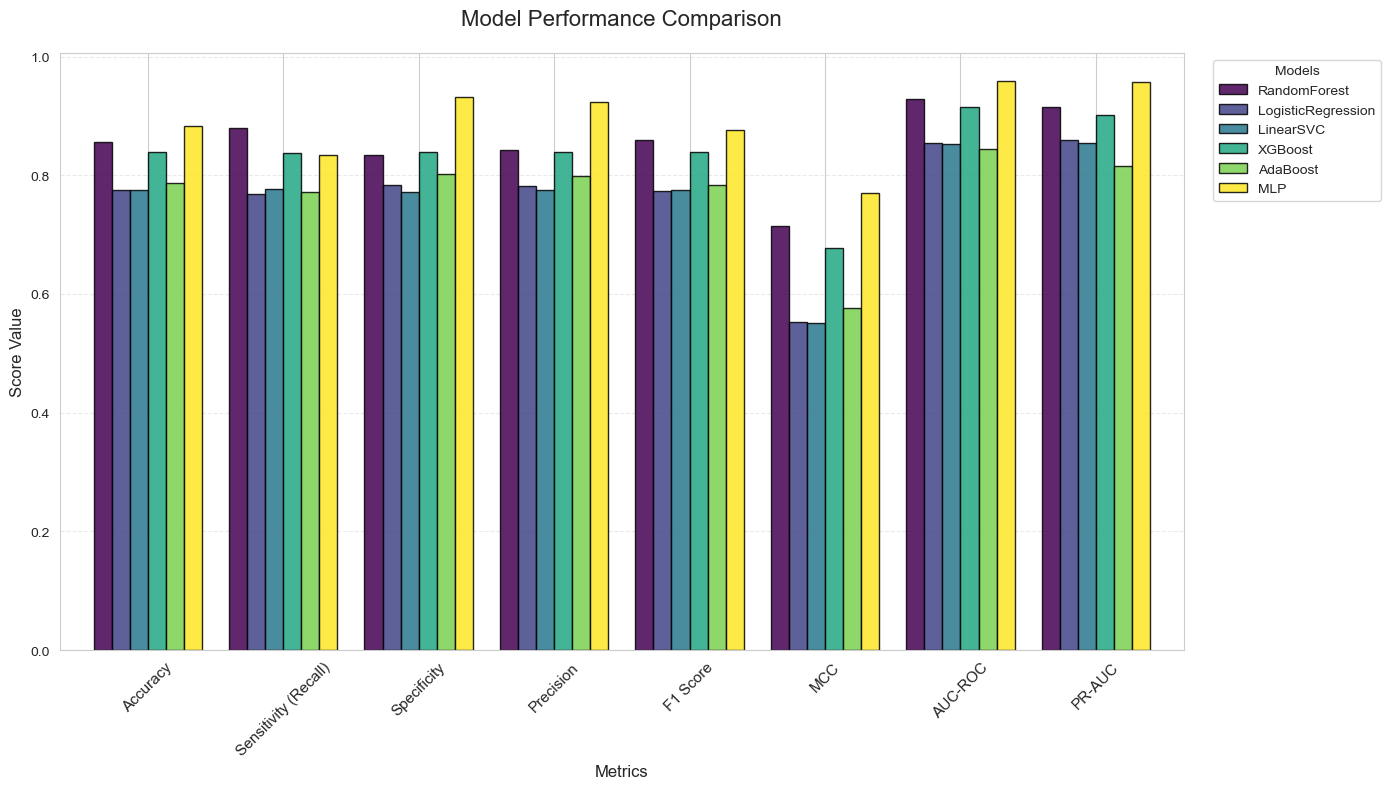

                                     Model Performance Comparison                                     
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┓
┃ Metric               ┃ RandomForest ┃ LogisticRegression ┃ LinearSVC ┃ XGBoost ┃ AdaBoost ┃  MLP   ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━┩
│ Accuracy             │    0.8567    │       0.7756       │  0.7747   │ 0.8386  │  0.7873  │ 0.8830 │
├──────────────────────┼──────────────┼────────────────────┼───────────┼─────────┼──────────┼────────┤
│ Sensitivity (Recall) │    0.8789    │       0.7679       │  0.7776   │ 0.8379  │  0.7723  │ 0.8348 │
├──────────────────────┼──────────────┼────────────────────┼───────────┼─────────┼──────────┼────────┤
│ Specificity          │    0.8345    │       0.7832       │  0.7717   │ 0.8394  │  0.8026  │ 0.9309 │
├──────────────────────┼──────────────┼────────────────────┼───────────┼─────────┼──────────┼────────┤
│ Precision            │    0.8427    │       0.7812       │  0.7743   │ 0.8398  │  0.7980  │ 0.9239 │
├──────────────────────┼──────────────┼────────────────────┼───────────┼─────────┼──────────┼────────┤
│ F1 Score             │    0.8599    │       0.7735       │  0.7750   │ 0.8385  │  0.7837  │ 0.8762 │
├──────────────────────┼──────────────┼────────────────────┼───────────┼─────────┼──────────┼────────┤
│ MCC                  │    0.7149    │       0.5526       │  0.5506   │ 0.6778  │  0.5766  │ 0.7706 │
├──────────────────────┼──────────────┼────────────────────┼───────────┼─────────┼──────────┼────────┤
│ AUC-ROC              │    0.9276    │       0.8549       │  0.8532   │ 0.9155  │  0.8449  │ 0.9584 │
├──────────────────────┼──────────────┼────────────────────┼───────────┼─────────┼──────────┼────────┤
│ PR-AUC               │    0.9149    │       0.8590       │  0.8536   │ 0.9010  │  0.8162  │ 0.9579 │
└──────────────────────┴──────────────┴────────────────────┴───────────┴─────────┴──────────┴────────┘

In [88]:
results["MLP"] = {
    "Accuracy": np.mean(metrics_results['accuracy']),
    "Sensitivity (Recall)": np.mean(metrics_results['sensitivity']),
    "Specificity": np.mean(metrics_results['specificity']),
    "Precision": np.mean(metrics_results['precision']),
    "F1 Score": np.mean(metrics_results['f1']),
    "AUC-ROC": np.mean(metrics_results['auc_roc']),
    "PR-AUC": np.mean(metrics_results['pr_auc']),
    "MCC": np.mean(metrics_results['mcc'])
}

# Convert to DataFrame with correct metric order
metric_order = ['Accuracy', 'Sensitivity (Recall)', 'Specificity', 'Precision',
                'F1 Score', 'MCC', 'AUC-ROC', 'PR-AUC']
results_df = pd.DataFrame.from_dict({
    model: {metric: val[0] if isinstance(val, tuple) else val 
           for metric, val in metrics.items()}
    for model, metrics in results.items()
}).T[metric_order]

# =====================
# MAINTAINED COLOR SCHEME PLOT
# =====================
plt.figure(figsize=(14, 8))
ax = results_df.T.plot(kind='bar', figsize=(14, 8),
                      colormap='viridis',  # Keeping original color scheme
                      edgecolor='black',
                      alpha=0.85,
                      width=0.8)

plt.title("Model Performance Comparison", fontsize=16, pad=20)
plt.ylabel("Score Value", fontsize=12)
plt.xlabel("Metrics", fontsize=12)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=10)
plt.legend(title="Models", bbox_to_anchor=(1.02, 1), 
          loc='upper left', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# =====================
# RICH TABLE WITH ORIGINAL COLORS
# =====================
from rich.console import Console
from rich.table import Table
from rich.style import Style

console = Console()

# Original color scheme
model_colors = {
    "Random Forest": Style(color="blue"),
    "KNN": Style(color="green"),
    "SVM": Style(color="red"),
    "XGBoost": Style(color="magenta"),
    "AdaBoost": Style(color="cyan"),
    "MLP": Style(color="yellow")
}

table = Table(title="Model Performance Comparison", show_lines=True, 
             header_style="bold black")

# Add metric column first
table.add_column("Metric", justify="left", style="bold")

# Add model columns with original colors
for model in results_df.index:
    table.add_column(model, justify="center", style=model_colors.get(model, ""))

# Add rows in correct order
for metric in metric_order:
    row = [metric]
    for model in results_df.index:
        value = results_df.loc[model, metric]
        row.append(f"{value:.4f}")
    table.add_row(*row)

console.print(table)